# 🩺 Diabetes Prediction with Logistic Regression

## Project Overview
This notebook uses logistic regression to predict diabetes based on patient characteristics.

### Features:
- **Gender**: Male/Female
- **Age**: Patient age
- **Hypertension**: Presence of hypertension (0/1)
- **Heart Disease**: Presence of heart disease (0/1)
- **Smoking History**: Smoking status
- **BMI**: Body Mass Index
- **HbA1c Level**: Glycated hemoglobin level
- **Blood Glucose Level**: Blood glucose concentration

### Target:
- **Diabetes**: Presence of diabetes (0/1)

### Business Impact:
- Early diabetes detection
- Preventive healthcare
- Risk assessment for patients

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load the dataset
try:
    df = pd.read_csv('diabetes.csv')
    print(f"✅ Dataset loaded successfully!")
    print(f"📊 Shape: {df.shape}")
    print(f"📁 Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
except FileNotFoundError:
    print("❌ Dataset file not found! Please ensure diabetes.csv is in the current directory.")

✅ Dataset loaded successfully!
📊 Shape: (100000, 9)
📁 Memory usage: 15.78 MB


In [3]:
# Display basic information
print("📋 Dataset Information:")
print("=" * 50)
df.info()

print("\n�� First few rows:")
print("=" * 50)
display(df.head())

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

�� First few rows:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
# Check for missing values
print("🔍 Missing Values Analysis:")
print("=" * 50)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False)

if len(missing_df) > 0:
    display(missing_df)
else:
    print("✅ No missing values found!")

# Check data types
print("\n📊 Data Types:")
print("=" * 50)
print(df.dtypes)

🔍 Missing Values Analysis:
✅ No missing values found!

📊 Data Types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


🎯 Target Variable Analysis:
Unique values in 'diabetes' column: [0 1]

📊 Diabetes Distribution:
No Diabetes: 91,500 patients (91.5%)
Diabetes: 8,500 patients (8.5%)


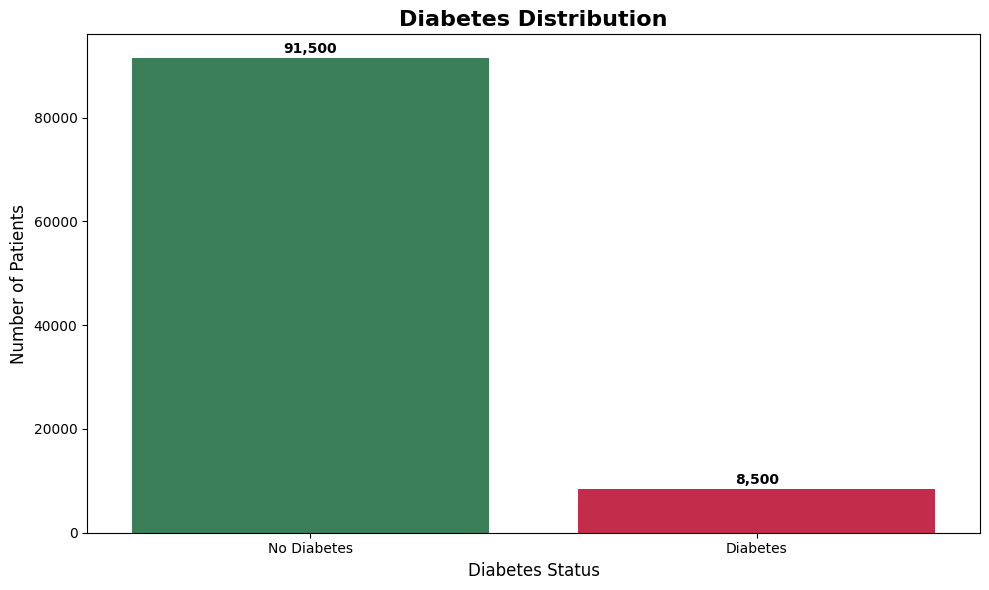


⚖️ Class Balance Check:
Majority class percentage: 91.5%
Minority class percentage: 8.5%
⚠️ Warning: Significant class imbalance detected!
💡 Consider using techniques like SMOTE or class weights.


In [5]:
# Analyze the target variable (diabetes)
print("🎯 Target Variable Analysis:")
print("=" * 50)

# Check unique values in diabetes column
print(f"Unique values in 'diabetes' column: {df['diabetes'].unique()}")

# Distribution of diabetes
diabetes_counts = df['diabetes'].value_counts()
diabetes_percentages = df['diabetes'].value_counts(normalize=True) * 100

print("\n📊 Diabetes Distribution:")
for diabetes_type, count in diabetes_counts.items():
    percentage = diabetes_percentages[diabetes_type]
    status = "No Diabetes" if diabetes_type == 0 else "Diabetes"
    print(f"{status}: {count:,} patients ({percentage:.1f}%)")

# Visualize diabetes distribution
plt.figure(figsize=(10, 6))
colors = ['#2E8B57', '#DC143C']  # Green for no diabetes, Red for diabetes

ax = sns.countplot(data=df, x='diabetes', palette=colors)
plt.title('Diabetes Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Diabetes Status', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])

# Add value labels on bars
for i, v in enumerate(diabetes_counts.values):
    ax.text(i, v + max(diabetes_counts) * 0.01, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Check for class imbalance
print(f"\n⚖️ Class Balance Check:")
print(f"Majority class percentage: {max(diabetes_percentages):.1f}%")
print(f"Minority class percentage: {min(diabetes_percentages):.1f}%")

if max(diabetes_percentages) > 80:
    print("⚠️ Warning: Significant class imbalance detected!")
    print("💡 Consider using techniques like SMOTE or class weights.")

�� Numerical Features Analysis:

📈 Statistical Summary:


,age,bmi,HbA1c_level,blood_glucose_level
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,27.320767,5.527507,138.058060
std,22.516840,6.636783,1.070672,40.708136
min,0.080000,10.010000,3.500000,80.000000
25%,24.000000,23.630000,4.800000,100.000000
50%,43.000000,27.320000,5.800000,140.000000
75%,60.000000,29.580000,6.200000,159.000000
max,80.000000,95.690000,9.000000,300.000000


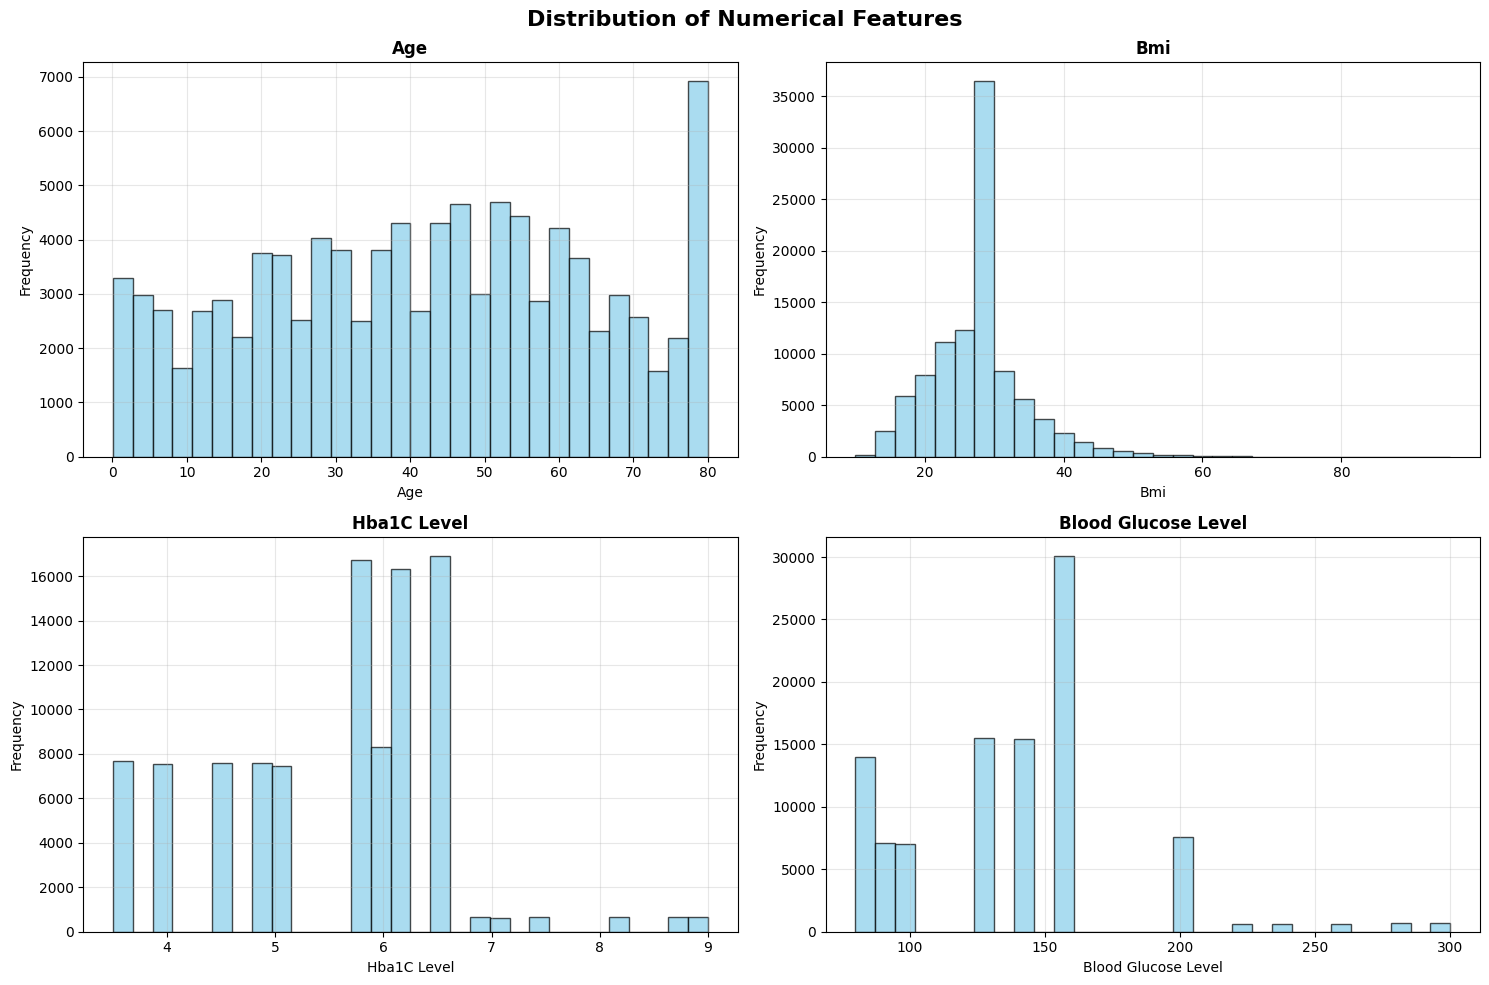

In [6]:
# Analyze numerical features
print("�� Numerical Features Analysis:")
print("=" * 50)

# Select numerical columns
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# Display statistics
print("\n📈 Statistical Summary:")
display(df[numerical_cols].describe())

# Visualize numerical features distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

for i, col in enumerate(numerical_cols):
    row = i // 2
    col_idx = i % 2
    
    # Create histogram
    axes[row, col_idx].hist(df[col], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[row, col_idx].set_title(f'{col.replace("_", " ").title()}', fontweight='bold')
    axes[row, col_idx].set_xlabel(col.replace('_', ' ').title())
    axes[row, col_idx].set_ylabel('Frequency')
    axes[row, col_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

📊 Categorical Features Analysis:

📊 Gender Distribution:
  Female: 58,552 (58.6%)
  Male: 41,430 (41.4%)
  Other: 18 (0.0%)

📊 Hypertension Distribution:
  0: 92,515 (92.5%)
  1: 7,485 (7.5%)

📊 Heart Disease Distribution:
  0: 96,058 (96.1%)
  1: 3,942 (3.9%)

📊 Smoking History Distribution:
  No Info: 35,816 (35.8%)
  never: 35,095 (35.1%)
  former: 9,352 (9.4%)
  current: 9,286 (9.3%)
  not current: 6,447 (6.4%)
  ever: 4,004 (4.0%)


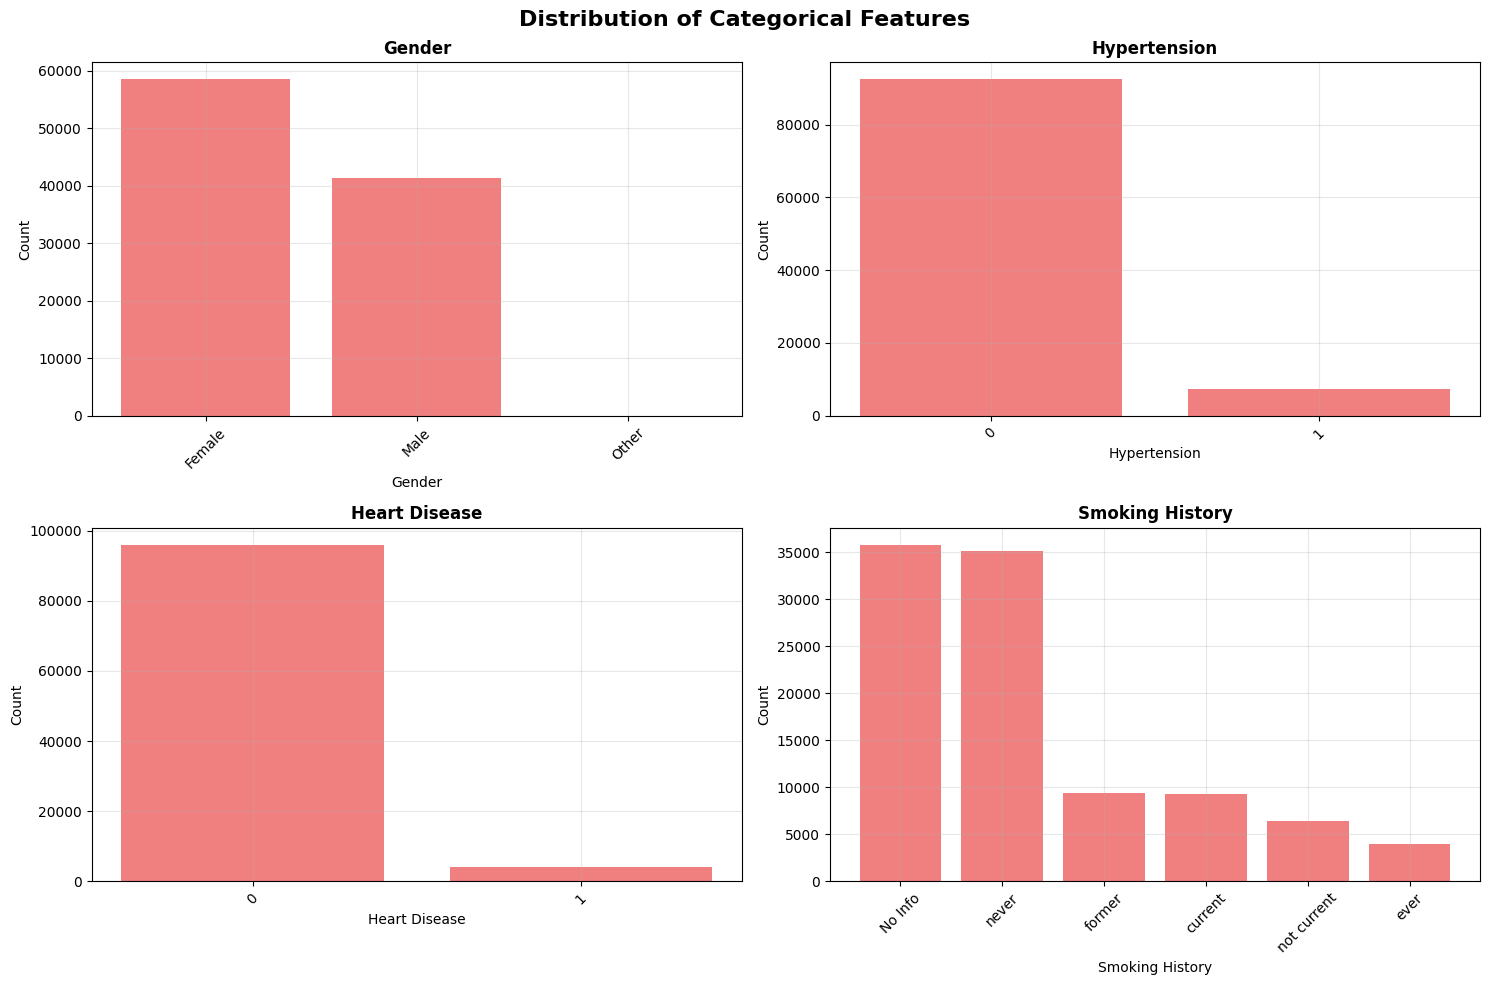

In [7]:
# Analyze categorical features
print("📊 Categorical Features Analysis:")
print("=" * 50)

# Select categorical columns
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'smoking_history']

# Display value counts for each categorical feature
for col in categorical_cols:
    print(f"\n📊 {col.replace('_', ' ').title()} Distribution:")
    value_counts = df[col].value_counts()
    for value, count in value_counts.items():
        percentage = (count / len(df)) * 100
        print(f"  {value}: {count:,} ({percentage:.1f}%)")

# Visualize categorical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold')

for i, col in enumerate(categorical_cols):
    row = i // 2
    col_idx = i % 2
    
    # Create bar plot
    value_counts = df[col].value_counts()
    axes[row, col_idx].bar(range(len(value_counts)), value_counts.values, color='lightcoral')
    axes[row, col_idx].set_title(f'{col.replace("_", " ").title()}', fontweight='bold')
    axes[row, col_idx].set_xlabel(col.replace('_', ' ').title())
    axes[row, col_idx].set_ylabel('Count')
    axes[row, col_idx].set_xticks(range(len(value_counts)))
    axes[row, col_idx].set_xticklabels(value_counts.index, rotation=45)
    axes[row, col_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Feature Engineering and Data Preprocessing
print("🔧 Feature Engineering and Preprocessing:")
print("=" * 50)

# Create a copy for preprocessing
df_processed = df.copy()

# Encode categorical variables
label_encoders = {}
categorical_features = ['gender', 'smoking_history']

for feature in categorical_features:
    le = LabelEncoder()
    df_processed[feature] = le.fit_transform(df_processed[feature])
    label_encoders[feature] = le
    print(f"✅ Encoded {feature}: {len(le.classes_)} unique values")

# Binary features are already encoded (hypertension, heart_disease)
print("✅ Binary features (hypertension, heart_disease) already encoded")

# Check the processed data
print(f"\n📊 Processed data shape: {df_processed.shape}")
print(f"📊 Data types after encoding:")
print(df_processed.dtypes)

🔧 Feature Engineering and Preprocessing:
✅ Encoded gender: 3 unique values
✅ Encoded smoking_history: 6 unique values
✅ Binary features (hypertension, heart_disease) already encoded

📊 Processed data shape: (100000, 9)
📊 Data types after encoding:
gender                   int64
age                    float64
hypertension             int64
heart_disease            int64
smoking_history          int64
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object


In [11]:
# Prepare features and target
print("�� Preparing Features and Target:")
print("=" * 50)

# Select features (all columns except diabetes)
feature_columns = [col for col in df_processed.columns if col != 'diabetes']
X = df_processed[feature_columns]
y = df_processed['diabetes']

print(f"📊 Feature matrix shape: {X.shape}")
print(f"📊 Target variable shape: {y.shape}")
print(f"📊 Features used: {list(X.columns)}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Training set: {X_train.shape[0]:,} samples")
print(f"📊 Test set: {X_test.shape[0]:,} samples")
print(f"📊 Training diabetes rate: {y_train.mean():.1%}")
print(f"�� Test diabetes rate: {y_test.mean():.1%}")

�� Preparing Features and Target:
📊 Feature matrix shape: (100000, 8)
📊 Target variable shape: (100000,)
📊 Features used: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']

📊 Training set: 80,000 samples
📊 Test set: 20,000 samples
📊 Training diabetes rate: 8.5%
�� Test diabetes rate: 8.5%


In [12]:
# Scale numerical features
print("⚖️ Scaling Numerical Features:")
print("=" * 50)

# Identify numerical features
numerical_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# Create scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print("✅ Features scaled successfully!")
print(f"�� Scaled features: {numerical_features}")
print(f"📊 Non-scaled features: {[col for col in X.columns if col not in numerical_features]}")

⚖️ Scaling Numerical Features:
✅ Features scaled successfully!
�� Scaled features: ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
📊 Non-scaled features: ['gender', 'hypertension', 'heart_disease', 'smoking_history']


In [13]:
# Train Logistic Regression Model
print("🤖 Training Logistic Regression Model:")
print("=" * 50)

# Initialize model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'  # Handle class imbalance
)

# Train model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test_scaled)
y_pred_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"✅ Model training completed!")
print(f"📊 Accuracy: {accuracy:.3f} ({accuracy:.1%})")
print(f"📊 ROC AUC: {roc_auc:.3f}")

# Model coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logistic_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\n🔍 Top 5 Most Important Features:")
for i, (_, row) in enumerate(coefficients.head(5).iterrows(), 1):
    print(f"{i}. {row['Feature']}: {row['Coefficient']:.3f}")

🤖 Training Logistic Regression Model:
✅ Model training completed!
📊 Accuracy: 0.887 (88.8%)
📊 ROC AUC: 0.962

🔍 Top 5 Most Important Features:
1. HbA1c_level: 2.313
2. blood_glucose_level: 1.289
3. age: 1.094
4. hypertension: 0.880
5. heart_disease: 0.830


📊 Model Evaluation:
📋 Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.99      0.89      0.94     18300
    Diabetes       0.42      0.89      0.57      1700

    accuracy                           0.89     20000
   macro avg       0.71      0.89      0.75     20000
weighted avg       0.94      0.89      0.90     20000



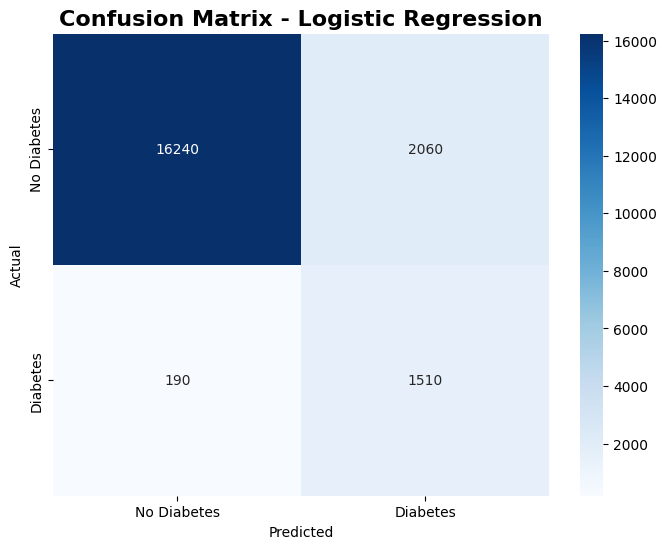

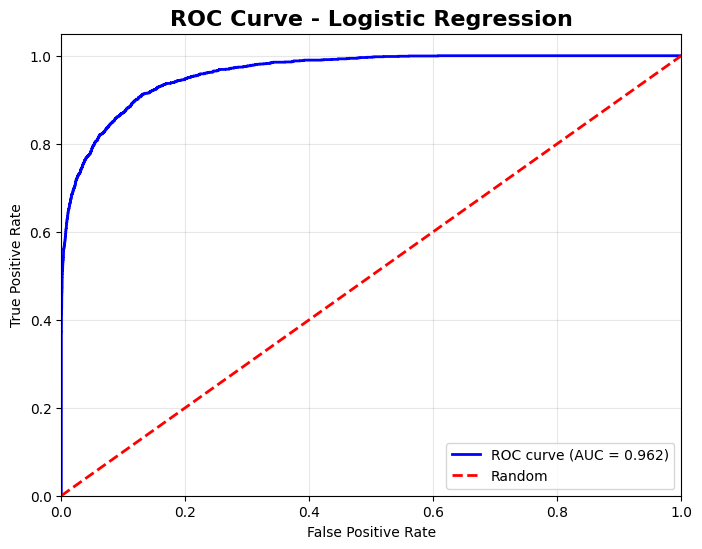

In [14]:
# Model Evaluation
print("📊 Model Evaluation:")
print("=" * 50)

# Classification report
print("📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'], 
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=16, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression', fontsize=16, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()